# Parse Tree Visualizations

This notebook demonstrates how to generate and visualize parse trees from hearing utterances using the Tokenizer class and NLTK.

In [ ]:
import pandas as pd
import random
from pathlib import Path

from src import HearingLoader, HearingTagger
from src.Tokenizer import Tokenizer
from src.dataclasses.Hearing import TaggedHearing

# Set random seed for reproducibility
random.seed(42)

In [ ]:
from pathlib import Path
import subprocess
import zipfile
import os

#This is where the unzipped corpus file is stored
CORPUS_FILE_PATH = 'DH2024_Corpus_Release/'
corpus_dir = Path(CORPUS_FILE_PATH)
zip_path = Path("digitaldemocracy-2015-2018/DH2024_Corpus_Release.zip")
repo_dir = Path("digitaldemocracy-2015-2018")

# Clone repository if not present
if not repo_dir.is_dir():
    print("Corpus directory not found. Cloning repository...")
    subprocess.run(
        ["git", "clone", "https://huggingface.co/datasets/iatpp/digitaldemocracy-2015-2018"],
        check=True,
    )
    print("Repository cloned successfully.")

# Extract zip file if corpus directory doesn't exist
if not corpus_dir.is_dir():
    if zip_path.exists():
        print(f"Extracting {zip_path}...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall('.')
        print("Extraction complete.")
    else:
        print(f"Error: {zip_path} not found!")
else:
    print(f"Corpus already extracted at {corpus_dir}")

In [ ]:
# Load hearings from utterances_sample.csv
utterances_df = pd.read_csv('./utterances_sample.csv')

# Initialize loader and tagger
loader = HearingLoader(corpus_path='DH2024_Corpus_Release/')
tagger = HearingTagger()

hearings = loader.load_all_committee_hearings()
relevant_hearings = [h for h in hearings if h.bid != 'CA_NO BILL DISCUSSED']
print(len(hearings))
print(len(relevant_hearings))

In [ ]:
import random

# Set random seed for reproducibility
random.seed(42)

# Randomly sample 20 hearings
sampled_hearings = random.sample(relevant_hearings, 5)
sampled_hearings = [tagger(h) for h in sampled_hearings]

In [ ]:
# Display the sampled hearings
sampled_hearings

In [ ]:
# Initialize the tokenizer
tokenizer = Tokenizer()

# Generate parse trees for sampled hearings
parse_results = []

for hearing in sampled_hearings:
    result = {
        'bid': hearing.bid,
        'hid': hearing.hid,
        'num_utterances': len(hearing.utterances),
        'tokens': tokenizer.tokenize_utterances(hearing),
        'parse_node': tokenizer.parse(hearing),
        'nltk_tree': None,
        'all_parses': []
    }
    
    # Get NLTK tree if parse succeeded
    if result['parse_node']:
        result['nltk_tree'] = result['parse_node'].to_nltk_tree()
        # Also get alternative parses
        result['all_parses'] = tokenizer.get_all_parses_as_nltk_trees(hearing, max_parses=3)
    
    parse_results.append(result)
    
print(f"\nParse results:")
for r in parse_results:
    status = "✓ Success" if r['parse_node'] else "✗ Failed"
    num_tokens = len(r['tokens'])
    num_parses = len(r['all_parses'])
    print(f"  {r['bid']}: {status} ({num_tokens} tokens, {num_parses} possible parses)")

## Visualize Parse Trees

Now we'll visualize the parse trees using NLTK's tree visualization capabilities.

In [ ]:
# Display parse trees for each hearing
for i, result in enumerate(parse_results):
    print(f"\n{'='*80}")
    print(f"Hearing {i+1}: {result['bid']} (hid: {result['hid']})")
    print(f"{'='*80}")
    print(f"Utterances: {result['num_utterances']}")
    print(f"Tokens: {len(result['tokens'])}")
    
    # Show token sequence
    print("\nToken sequence (SpeakerPositionEnum):")
    token_names = [token[0].name for token in result['tokens']]
    print("  " + " -> ".join(token_names[:10]) + ("..." if len(token_names) > 10 else ""))
    
    if result['nltk_tree']:
        print(f"\nFound {len(result['all_parses'])} possible parse(s)")
        print("\nPrimary Parse Tree:")
        print(result['nltk_tree'])
        print("\nPretty Print:")
        result['nltk_tree'].pretty_print()
    else:
        print("\n⚠ No valid parse found for this hearing")
        print("This may indicate that the utterance sequence doesn't match any grammar rules.")

## Summary Statistics

In [ ]:
# Summary statistics
successful_parses = sum(1 for r in parse_results if r['parse_node'] is not None)
ambiguous_parses = sum(1 for r in parse_results if len(r['all_parses']) > 1)

print("Parse Tree Generation Summary")
print("=" * 50)
print(f"Total hearings processed: {len(parse_results)}")
print(f"Successful parses: {successful_parses} ({successful_parses/len(parse_results)*100:.1f}%)")
print(f"Failed parses: {len(parse_results) - successful_parses}")
print(f"Ambiguous parses (multiple valid trees): {ambiguous_parses}")
print()

# Token statistics
all_tokens = [token for r in parse_results for token in r['tokens']]
print(f"Total tokens across all hearings: {len(all_tokens)}")

# Distribution of speaker positions
from collections import Counter
token_distribution = Counter([token[0].name for token in all_tokens])
print("\nToken distribution (SpeakerPositionEnum):")
for pos, count in token_distribution.most_common():
    print(f"  {pos}: {count} ({count/len(all_tokens)*100:.1f}%)")

## Saving Results

Save the parse trees for later analysis.

In [ ]:
# import pickle

# # Save parse results
# output_file = "parse_tree_results.pkl"
# with open(output_file, 'wb') as f:
#     pickle.dump(parse_results, f)

# print(f"Parse results saved to: {output_file}")
# print("\nTo load later:")
# print("  with open('parse_tree_results.pkl', 'rb') as f:")
# print("      parse_results = pickle.load(f)")

## Export Trees as String Representations

For documentation or reporting purposes, export the tree structures.

In [ ]:
# Export tree strings to a text file
output_text_file = "parse_trees.txt"

with open(output_text_file, 'w', encoding='utf-8') as f:
    for i, result in enumerate(parse_results):
        f.write(f"{'='*80}\n")
        f.write(f"Hearing {i+1}: {result['bid']} (hid: {result['hid']})\n")
        f.write(f"{'='*80}\n\n")
        
        if result['nltk_tree']:
            f.write("Parse Tree (bracket notation):\n")
            f.write(str(result['nltk_tree']))
            f.write("\n\n")
            
            f.write("Parse Tree (indented):\n")
            f.write(result['nltk_tree'].pformat(margin=100))
            f.write("\n\n")
            
            if len(result['all_parses']) > 1:
                f.write(f"Alternative parses: {len(result['all_parses']) - 1}\n\n")
        else:
            f.write("No valid parse found\n\n")
        
        f.write("\n")

print(f"Parse trees exported to: {output_text_file}")

# Section speaker position requirements

In [24]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from collections import defaultdict
from src.Grammar import Hearing_Grammar
from src.enums.SectionEnum import SectionEnum
from src.speakers.enums.SpeakerPositionEnum import SpeakerPositionEnum

# Filter rules of the form (SectionEnum, SpeakerPositionEnum)
# Group by SectionEnum
section_speaker_map = defaultdict(list)

for rule in Hearing_Grammar:
    if len(rule) == 2:
        left, right = rule
        # Check if left is SectionEnum and right is SpeakerPositionEnum
        if isinstance(left, SectionEnum) and isinstance(right, SpeakerPositionEnum):
            section_speaker_map[left].append(right)


# Create a mapping of SpeakerPositionEnum values to numeric positions
# Sort by descending value (higher enum values first)
all_speakers = set()
for speakers in section_speaker_map.values():
    all_speakers.update(speakers)

sorted_speakers = sorted(all_speakers, key=lambda x: x.value, reverse=True)
speaker_to_position = {speaker: i for i, speaker in enumerate(sorted_speakers)}
position_to_speaker = {v: k for k, v in speaker_to_position.items()}

# Get sections in the order they appear in SectionEnum
section_order = [
    SectionEnum.INTRO,
    SectionEnum.PRESENTATION,
    SectionEnum.LEGISLATOR_DISCUSSION,
    SectionEnum.EXPERT_TESTIMONY,
    SectionEnum.PUBLIC_COMMENTS,
    SectionEnum.CLOSING_REMARKS,
    SectionEnum.VOTE,
    SectionEnum.OTHER,
]
# Filter to only sections that have speaker rules
ordered_sections = [s for s in section_order if s in section_speaker_map]

print(f"Found {len(section_speaker_map)} sections with speaker position rules:")
for section in ordered_sections:
    speakers = section_speaker_map[section]
    speaker_names = [
        f"{s.name}({s.value})"
        for s in sorted(
                speakers,
                key=lambda x: x.value,
                reverse=True
            )
        ]
    print(f"  {section.name}: {speaker_names}")

Found 8 sections with speaker position rules:
  INTRO: ['SECRETARY(9)', 'PRESIDING_CHAIR(8)']
  PRESENTATION: ['PRESIDING_CHAIR(8)', 'BILL_AUTHOR(4)']
  LEGISLATOR_DISCUSSION: ['SECRETARY(9)', 'PRESIDING_CHAIR(8)', 'CHAIRMAN(7)', 'VICE_CHAIRMAN(6)', 'COMMITTEE_MEMBER(5)', 'BILL_AUTHOR(4)']
  EXPERT_TESTIMONY: ['SECRETARY(9)', 'PRESIDING_CHAIR(8)', 'CHAIRMAN(7)', 'VICE_CHAIRMAN(6)', 'COMMITTEE_MEMBER(5)', 'BILL_AUTHOR(4)', 'EXPERT(2)', 'NONLEGISLATOR(1)']
  PUBLIC_COMMENTS: ['SECRETARY(9)', 'PRESIDING_CHAIR(8)', 'CHAIRMAN(7)', 'VICE_CHAIRMAN(6)', 'COMMITTEE_MEMBER(5)', 'NONLEGISLATOR(1)', 'PUBLIC(0)']
  CLOSING_REMARKS: ['PRESIDING_CHAIR(8)', 'BILL_AUTHOR(4)']
  VOTE: ['SECRETARY(9)', 'PRESIDING_CHAIR(8)', 'CHAIRMAN(7)', 'VICE_CHAIRMAN(6)', 'COMMITTEE_MEMBER(5)', 'BILL_AUTHOR(4)']
  OTHER: ['SECRETARY(9)', 'PRESIDING_CHAIR(8)', 'CHAIRMAN(7)', 'VICE_CHAIRMAN(6)', 'COMMITTEE_MEMBER(5)', 'LEGISLATOR(3)']


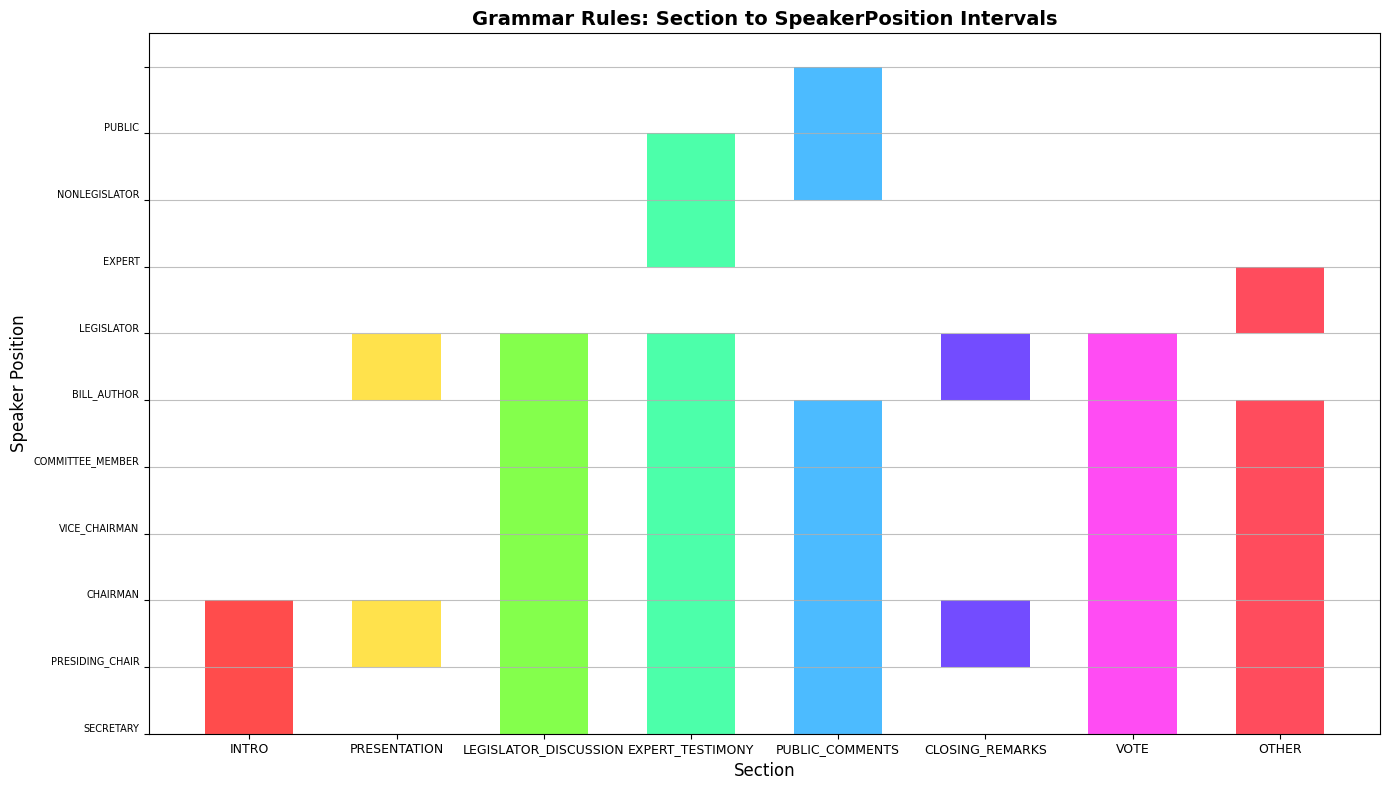


Visualization shows 8 sections mapped to 10 speaker positions
Bars show only the ranges where speakers are allowed (no overlap with disallowed positions)


In [25]:
# Create interval tree visualization using individual segments
fig, ax = plt.subplots(figsize=(14, 8))

num_sections = len(ordered_sections)

# Use HSV colormap for distinct colors
colors = plt.get_cmap('hsv', num_sections)

# Create intervals for each section by drawing individual segments
for section_idx, section in enumerate(ordered_sections):
    speakers = section_speaker_map[section]

    # Get positions for this section's speakers
    positions = sorted([speaker_to_position[s] for s in speakers])

    # Draw separate segments for each consecutive speaker position
    color = colors(section_idx)
    x_position = section_idx

    # Group consecutive positions into ranges
    ranges = []
    if positions:
        start = positions[0]
        end = positions[0]

        for pos in positions[1:]:
            if pos == end + 1:
                end = pos
            else:
                ranges.append((start, end))
                start = pos
                end = pos
        ranges.append((start, end))

    # Draw each range as a separate vertical bar
    for start, end in ranges:
        height = end - start + 1
        ax.bar(
            x_position,
            height=height,
            bottom=start,
            width=0.6,
            color=color,
            alpha=0.7
        )

# Configure axes
ax.set_xticks(range(num_sections))
ax.set_xticklabels(
    [section.name for section in ordered_sections],
    rotation=0,
    ha='center',
    fontsize=9
)

ax.set_yticks(range(len(speaker_to_position) + 1))
ax.set_yticklabels(
    [
        f"{position_to_speaker[i].name}"
        for i in range(len(speaker_to_position))
    ] + [""],
    fontsize=7,
    va="bottom"
)

ax.set_xlabel('Section', fontsize=12)
ax.set_ylabel('Speaker Position', fontsize=12)
ax.set_title('Grammar Rules: Section to SpeakerPosition Intervals', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.8, linestyle='-')

plt.tight_layout()
plt.show()

print(f"\nVisualization shows {num_sections} sections mapped to {len(speaker_to_position)} speaker positions")
print("Bars show only the ranges where speakers are allowed (no overlap with disallowed positions)")